# Train and Validate
* Train a model across the specified training sites and sampling approach
* Validate the model at the excluded site

## Todo
* Pull out probabilities using model.predict_proba(observations_to_predict)

In [1]:
import pathlib
import numpy
import dask.distributed
import pandas
import joblib

module_path = pathlib.Path.cwd().parent / 'scripts'
import sys
if str(module_path) not in sys.path:
    sys.path.append(str(module_path))
import utils
import sentinel2
import training
import sampling
import plotting

%load_ext autoreload
%autoreload 2

C:\Users\pearsonra\.conda\envs\satellite\Lib\site-packages\dask\array\chunk_types.py:131: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  import scipy.sparse
C:\Users\pearsonra\.conda\envs\satellite\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


# Values to edit

In [2]:
sample_method = "sampling_2"
method_2_threshold = .8 # 1.0 .99 .98 .97 .95 .90
test_threshold = 0.1
max_cloud_cover = 5 # percentage
low_tide_delta_hrs = 1
low_tide_delta_mins = 0

In [3]:
# View the amount of training data for the selected sampling apporach
samples_per_site = pandas.read_csv(utils.get_samples_summary_file_path(sample_method, method_2_threshold, max_cloud_cover=max_cloud_cover,
                                                                       low_tide_delta_hrs=low_tide_delta_hrs, low_tide_delta_mins=low_tide_delta_mins))
samples_per_site.set_index('Site').astype(int) 
'''[['Seagrass', 'Seagrass submerged', 'Gracilaria', 'Gracilaria submerged', 'Ulva', 'Ulva mats', 'Unvegetated',
'Water', 'Terrestrial', 'Submerged vegetation', 'Microphytobenthos', 'Rock', 'Saltmarsh']]# , 'Shadow', 'Glare']]'''
# 'Cystophora', 'Hormosira', 'Filamentous brown algae', 'Brown algae mixed', 'Green algae mixed', 'Red algae mixed', 
samples_per_site

,Site,Glare,Gracilaria,Gracilaria submerged,Microphytobenthos,Rock,Saltmarsh,Seagrass,Seagrass submerged,Shadow,Submerged vegetation,Terrestrial,Ulva,Ulva mats,Unvegetated,Water
0,CatlinsLake,0.0,1532.0,1533.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25908.0,7112.0
1,CatlinsRiverMouth,84.0,0.0,0.0,0.0,180.0,0.0,748.0,0.0,0.0,0.0,1658.0,0.0,0.0,3958.0,358.0
2,Childrens,0.0,0.0,0.0,54.0,0.0,0.0,381.0,18.0,0.0,12.0,0.0,0.0,0.0,1476.0,2169.0
3,Duvauchelle,0.0,0.0,0.0,90.0,0.0,0.0,3360.0,840.0,21.0,0.0,0.0,0.0,0.0,3216.0,8154.0
4,Ihutai,0.0,7209.0,0.0,0.0,0.0,4719.0,6711.0,0.0,0.0,10407.0,1074.0,1263.0,5070.0,105399.0,24861.0
5,IveyBay_Feb26,0.0,0.0,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,0.0,0.0,46.0,0.0
6,IveyBay_Nov25,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,2.0,0.0,0.0,158.0,6.0
7,IveyBay_ThePoint_LeftBank_Oct24,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,12.0,46.0,0.0,0.0,0.0,188.0,410.0
8,LeftBank_Feb26,0.0,0.0,0.0,0.0,0.0,0.0,54.0,0.0,0.0,0.0,0.0,0.0,0.0,175.0,92.0
9,LeftBank_Nov25,0.0,0.0,0.0,0.0,0.0,0.0,88.0,0.0,0.0,0.0,0.0,82.0,0.0,94.0,126.0


In [4]:
samples_per_site.sum(axis=0)

Site                    CatlinsLakeCatlinsRiverMouthChildrensDuvauchel...
Glare                                                                86.0
Gracilaria                                                         8741.0
Gracilaria submerged                                               1542.0
Microphytobenthos                                                   261.0
Rock                                                                183.0
Saltmarsh                                                          4719.0
Seagrass                                                          13337.0
Seagrass submerged                                                 1423.0
Shadow                                                               42.0
Submerged vegetation                                              10498.0
Terrestrial                                                        2738.0
Ulva                                                               1503.0
Ulva mats                             

In [5]:
uav_classes_to_ignore = ['Shadow', 'Glare']

In [6]:
# Mappings of Satellite classes to consider from UAV classes - 100% purity
satellite_classes_5 = {'Seagrass': 1, 'Missing': 2, 'Unvegetated': 3, 'Water': 4, 'Seagrass submerged': 5, "Vegetated": 6}
satellite_classes_from_uav_classes_5 = {
    'Seagrass': ['Seagrass'],
    'Seagrass submerged': ['Seagrass submerged'],
    'Unvegetated': ['Unvegetated'],                            
    'Water': ['Water'],
    'Vegetated': ['Microphytobenthos'],
    'Missing': ['Gracilaria', 'Ulva', 'Cystophora', 'Hormosira', 'Gracilaria submerged', 'Submerged vegetation',
              'Brown algae mixed', 'Green algae mixed', 'Filamentous brown algae',
              'Ulva mats', 'Terrestrial', 'Red algae mixed', 'Saltmarsh', 'Rock'],
}

In [7]:
# Mappings of Satellite classes to consider from UAV classes - 100% purity
satellite_classes_4 = {'Seagrass': 1, 'Mixed': 2, 'Unvegetated': 3, 'Water': 4}
satellite_classes_from_uav_classes_4 = {
    'Seagrass': ['Seagrass', 'Seagrass submerged'],
    'Unvegetated': ['Saltmarsh', 'Unvegetated', 'Rock'],                            
    'Water': ['Water'],
    'Mixed': ['Gracilaria', 'Ulva', 'Cystophora', 'Hormosira', 'Gracilaria submerged', 'Submerged vegetation',
              'Brown algae mixed', 'Microphytobenthos', 'Green algae mixed', 'Filamentous brown algae',
              'Ulva mats', 'Terrestrial', 'Red algae mixed'],
}

In [8]:
# Mappings of Satellite classes to consider from UAV classes - 98% purity
satellite_classes_all = {'Seagrass': 1, 'Seagrass submerged': 2, 'Gracilaria': 3, 'Gracilaria submerged': 4, 
                           'Ulva': 5, 'Submerged vegetation': 9, 'Microphytobenthos': 10, 'Satmarsh': 14,
                           'Unvegetated': 15, 'Water': 16, 'Terrestrial': 18, 'Rock': 19, 'Mixed': 22,}
satellite_classes_from_uav_classes_all = {
    'Seagrass': ['Seagrass'],
    'Gracilaria': ['Gracilaria'],
    'Ulva': ['Ulva', 'Ulva mats'],
    'Satmarsh': ['Saltmarsh', ],
    'Terrestrial': ['Terrestrial'],
    'Unvegetated': ['Unvegetated'],                            
    'Water': ['Water'],
    'Mixed': ['Cystophora', 'Hormosira','Brown algae mixed', 'Green algae mixed', 
          'Filamentous brown algae', 'Red algae mixed'],
    'Submerged vegetation': ['Submerged vegetation'],
    'Gracilaria submerged': ['Gracilaria submerged'],
    'Seagrass submerged': ['Seagrass submerged'],
    'Rock': ['Rock'],
    'Microphytobenthos': ['Microphytobenthos'], 
}

In [9]:
# Mappings of Satellite classes to consider from UAV classes - 98% purity
satellite_classes_grouped = {'Seagrass': 1, 'Seagrass submerged': 2, 'Gracilaria': 3,  
                           'Ulva': 5, 'Submerged vegetation': 9, 'Microphytobenthos': 10, 'Satmarsh': 14,
                           'Unvegetated': 15, 'Water': 16, 'Terrestrial': 18, 'Rock': 19, 'Mixed': 22,}
satellite_classes_from_uav_classes_grouped = {
    'Seagrass': ['Seagrass'],
    'Gracilaria': ['Gracilaria', 'Gracilaria submerged'],
    'Ulva': ['Ulva', 'Ulva mats'],
    'Satmarsh': ['Saltmarsh', ],
    'Terrestrial': ['Terrestrial'],
    'Unvegetated': ['Unvegetated'],                            
    'Water': ['Water'],
    'Mixed': ['Cystophora', 'Hormosira','Brown algae mixed', 'Green algae mixed', 
          'Filamentous brown algae', 'Red algae mixed'],
    'Submerged vegetation': ['Submerged vegetation'],
    'Seagrass submerged': ['Seagrass submerged'],
    'Rock': ['Rock'],
    'Microphytobenthos': ['Microphytobenthos'], 
}

In [10]:
# Mappings of Satellite classes to consider from UAV classes - 98% purity
satellite_classes_9 = {'Seagrass': 1, 'Seagrass submerged': 2, 'Gracilaria': 3,  
                           'Ulva': 5, 'Submerged vegetation': 9, 'Microphytobenthos': 10,
                           'Water': 16, 'Small': 22, 'Other': 23,}
satellite_classes_from_uav_classes_9 = {
    'Seagrass': ['Seagrass'],
    'Gracilaria': ['Gracilaria', 'Gracilaria submerged'],
    'Ulva': ['Ulva', 'Ulva mats'],
    'Other': ['Unvegetated', 'Terrestrial', 'Saltmarsh', 'Rock'],                            
    'Water': ['Water'],
    'Small': ['Cystophora', 'Hormosira','Brown algae mixed', 'Green algae mixed', 
          'Filamentous brown algae', 'Red algae mixed'],
    'Submerged vegetation': ['Submerged vegetation'],
    'Seagrass submerged': ['Seagrass submerged'],
    'Microphytobenthos': ['Microphytobenthos'], 
}

In [11]:
all_training_sites =  ["CatlinsLake", "CatlinsRiverMouth", "Childrens", "Duvauchelle", "Robinsons", "Takamatua",
                       "Purau", "Ihutai", "IveyBay_Nov25", "IveyBay_Feb26", "LeftBank_Nov25", "LeftBank_Feb26",
                       "Paremata_Nov25", "Paremata_Feb26", "Paremata_Feb25", "ThePoint_Nov25", "ThePoint_Feb26",
                       "Takapuwahia_Nov25", "Takapuwahia_Feb26", "IveyBay_ThePoint_LeftBank_Oct24"]

training_sites_akaroa = ["Duvauchelle", "Robinsons", "Childrens", "Takamatua"] 
training_sites_SI = ["CatlinsLake", "CatlinsRiverMouth", "Childrens", "Duvauchelle", "Robinsons", "Takamatua",
                     "Purau", "Ihutai"] 

### Make sure you change the `model_file` name when experimenting

In [12]:
training_sites = all_training_sites # training_sites_SI all_training_sites ["Duvauchelle"]
models_path = utils.get_models_path(sample_method=sample_method, method_2_threshold=method_2_threshold,
                                    low_tide_delta_hrs=low_tide_delta_hrs, low_tide_delta_mins=low_tide_delta_mins,
                                    max_cloud_cover=max_cloud_cover)
model_file = models_path / f"test_on_{int(test_threshold*100)}_percent_all_classes.joblib"

satellite_classes = satellite_classes_all
satellite_classes_from_uav_classes = satellite_classes_from_uav_classes_all

# Cells to run
* Train and save model
* Review model
  * satellite bands of each UAV class
  * satellite bands of each satellite class
  * importance of satellite bands in trained model
* Validation
  * Predict excluded site
  * Plot confusion matrix comparing prediction to UAV classifications

In [13]:
cluster = dask.distributed.LocalCluster(
    threads_per_worker=1,   n_workers=4,                                 
    config={
        "distributed.worker.memory.target": 0.80, 
        "distributed.worker.memory.spill": 0.85,
        "distributed.worker.memory.pause": 0.90
    }
)
client = dask.distributed.Client(cluster)
display(client)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:59025/status,
Dashboard: http://127.0.0.1:59025/status,Workers: 4
Total threads: 4,Total memory: 31.73 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:59026,Workers: 4
Dashboard: http://127.0.0.1:59025/status,Total threads: 4
Started: Just now,Total memory: 31.73 GiB
Comm: tcp://127.0.0.1:59045,Total threads: 1
Dashboard: http://127.0.0.1:59046/status,Memory: 7.93 GiB
Nanny: tcp://127.0.0.1:59029,


In [15]:
data_path = utils.get_data_path()
utils.create_data_folders()
uav_labels_file = data_path / "ELF24505_ClassificationClasses.txt"
sample_folder = utils.get_samples_path(sample_method=sample_method, method_2_threshold=method_2_threshold, low_tide_delta_hrs=low_tide_delta_hrs,
                                       low_tide_delta_mins=low_tide_delta_mins, max_cloud_cover=max_cloud_cover)

validation_path = utils.get_validation_path(sample_method=sample_method, method_2_threshold=method_2_threshold, low_tide_delta_hrs=low_tide_delta_hrs,
                                            low_tide_delta_mins=low_tide_delta_mins, max_cloud_cover=max_cloud_cover)
test_prediction_file = validation_path / f"{int(test_threshold*100)}_percent_prediction_{model_file.stem}.csv"

### Train and save model

In [16]:
if not model_file.exists():

    # Split into test and train - todo
    training_dataframe, test_dataframe = training.randomise_to_test_and_training_across_sites(
        training_sites=training_sites,
        samples_path=sample_folder,
        uav_labels_file=uav_labels_file,
        uav_classes_to_ignore=uav_classes_to_ignore,
        satellite_classes=satellite_classes,
        satellite_from_uav_classes=satellite_classes_from_uav_classes,
        test_threshold=test_threshold)
    model, model_columns = training.train_random_forest_classifier(
        training_dataframe=training_dataframe,)
    
    # Save model and feature names
    joblib.dump(model, model_file); # , compress=3);
    model_columns.to_csv(model_file.with_name(f"{model_file.stem}_feature_names.csv"), index=False)

    # Save split test and train dataset
    joblib.dump(model, model_file); # , compress=3);
    training_dataframe.to_csv(model_file.with_name(f"{model_file.stem}_train.csv"), index=False)
    test_dataframe.to_csv(model_file.with_name(f"{model_file.stem}_test.csv"), index=False)
    
    # Save a record of the classes considered in training
    satellite_classes_dataframe = pandas.DataFrame.from_dict(satellite_classes, orient='index', columns=['satellite_class_id'])
    satellite_classes_dataframe['uav_class_ids'] = satellite_classes_dataframe.index.map(lambda key: f"{satellite_classes_from_uav_classes[key]}")
    satellite_classes_dataframe.to_csv(model_file.with_name(f"{model_file.stem}_class_mappings.csv"), index=True)

    # Save a summary of the training data
    training_data_summary=pandas.DataFrame(training_dataframe['satellite_class_id'].value_counts())
    training_data_summary["satellite_class_name"] = training_data_summary.index.map(lambda index: next((key for key, value in satellite_classes.items() if value == int(index)), None) )
    training_data_summary = training_data_summary[["satellite_class_name", "count"]] # Change column order
    training_data_summary.to_csv(model_file.with_name(f"{model_file.stem}_training_data_summary.csv"))
    
else:
    print(f"Model '{model_file.name}' already exists. Delete if you want to recreate it.")
    training_data_summary = pandas.read_csv(model_file.with_name(f"{model_file.stem}_training_data_summary.csv"))
    training_dataframe = pandas.read_csv(model_file.with_name(f"{model_file.stem}_train.csv"))
    test_dataframe = pandas.read_csv(model_file.with_name(f"{model_file.stem}_test.csv"))

training_data_summary

print("Write out test vs train values")

	Load in sites: ['CatlinsLake', 'CatlinsRiverMouth', 'Childrens', 'Duvauchelle', 'Robinsons', 'Takamatua', 'Purau', 'Ihutai', 'IveyBay_Nov25', 'IveyBay_Feb26', 'LeftBank_Nov25', 'LeftBank_Feb26', 'Paremata_Nov25', 'Paremata_Feb26', 'Paremata_Feb25', 'ThePoint_Nov25', 'ThePoint_Feb26', 'Takapuwahia_Nov25', 'Takapuwahia_Feb26', 'IveyBay_ThePoint_LeftBank_Oct24']
	Map UAV training ids to the specified satellite training ids
	Train a Random Forest Model
Write out test vs train values


In [17]:
training_data_summary

,satellite_class_name,count
satellite_class_id,,
15,Unvegetated,137666
16,Water,46134
1,Seagrass,11267
9,Submerged vegetation,8911
3,Gracilaria,7540
5,Ulva,5215
14,Satmarsh,4221
18,Terrestrial,2428
4,Gracilaria submerged,1388


### Review model

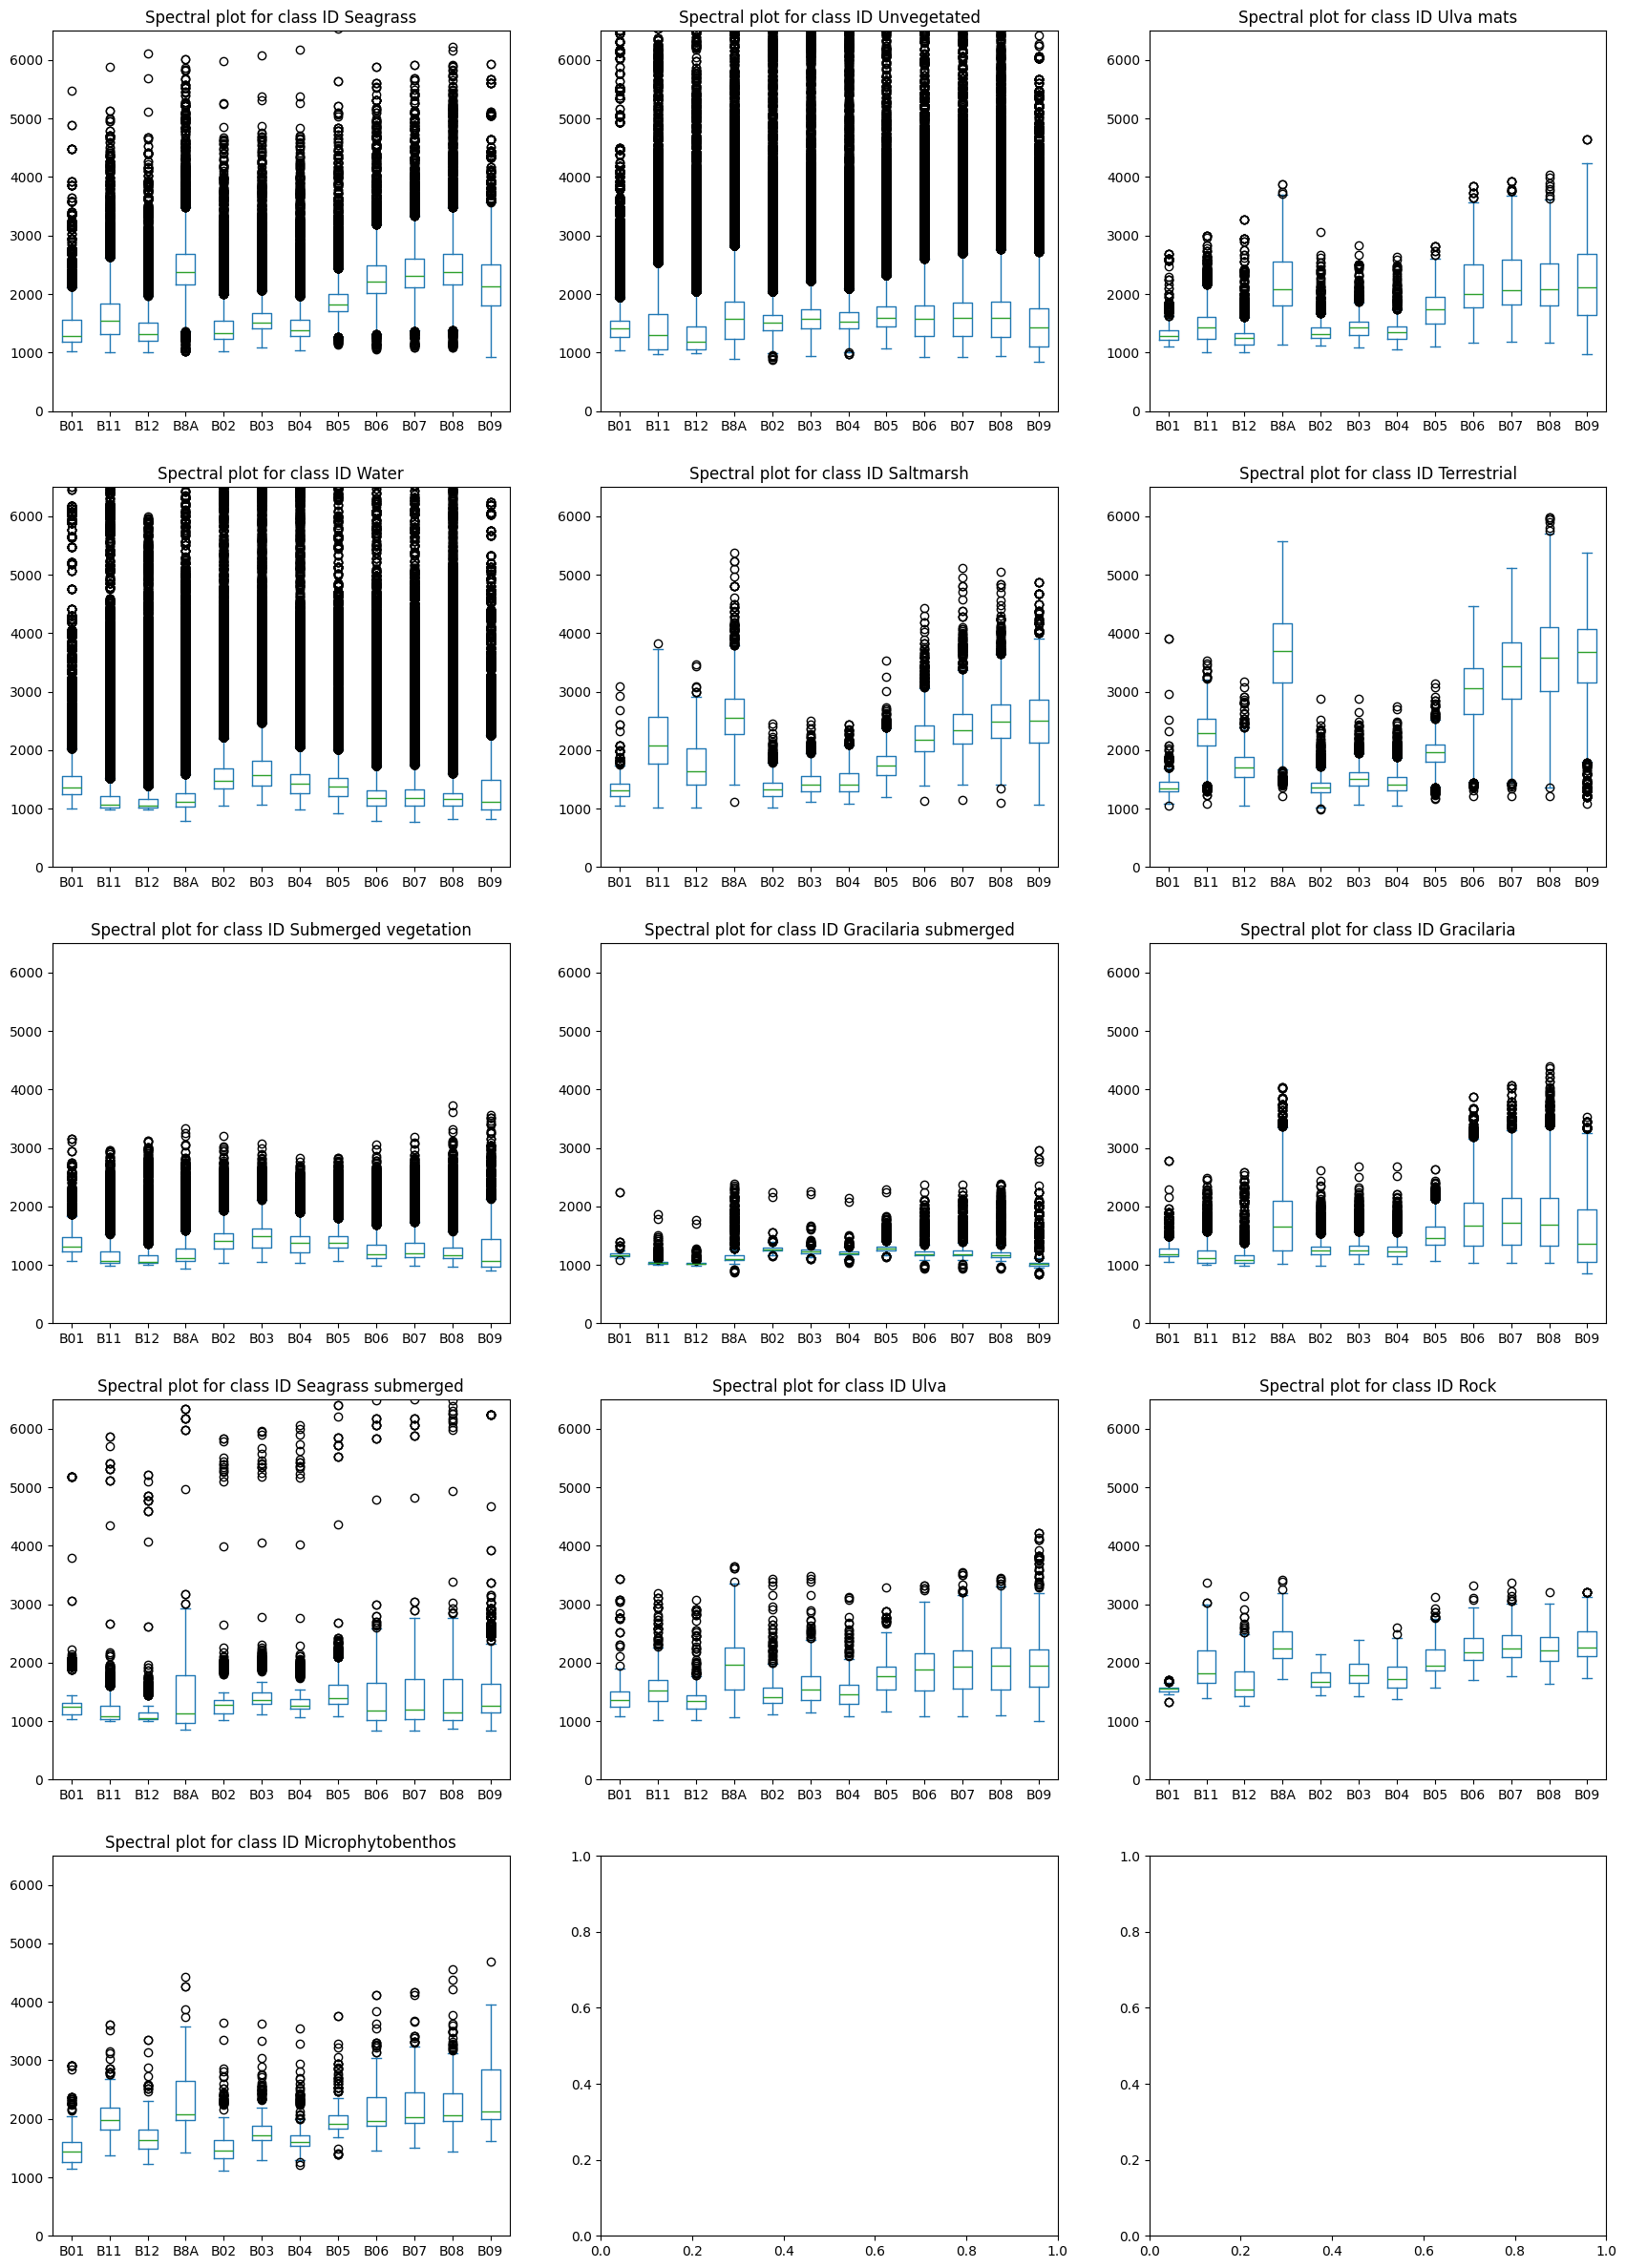

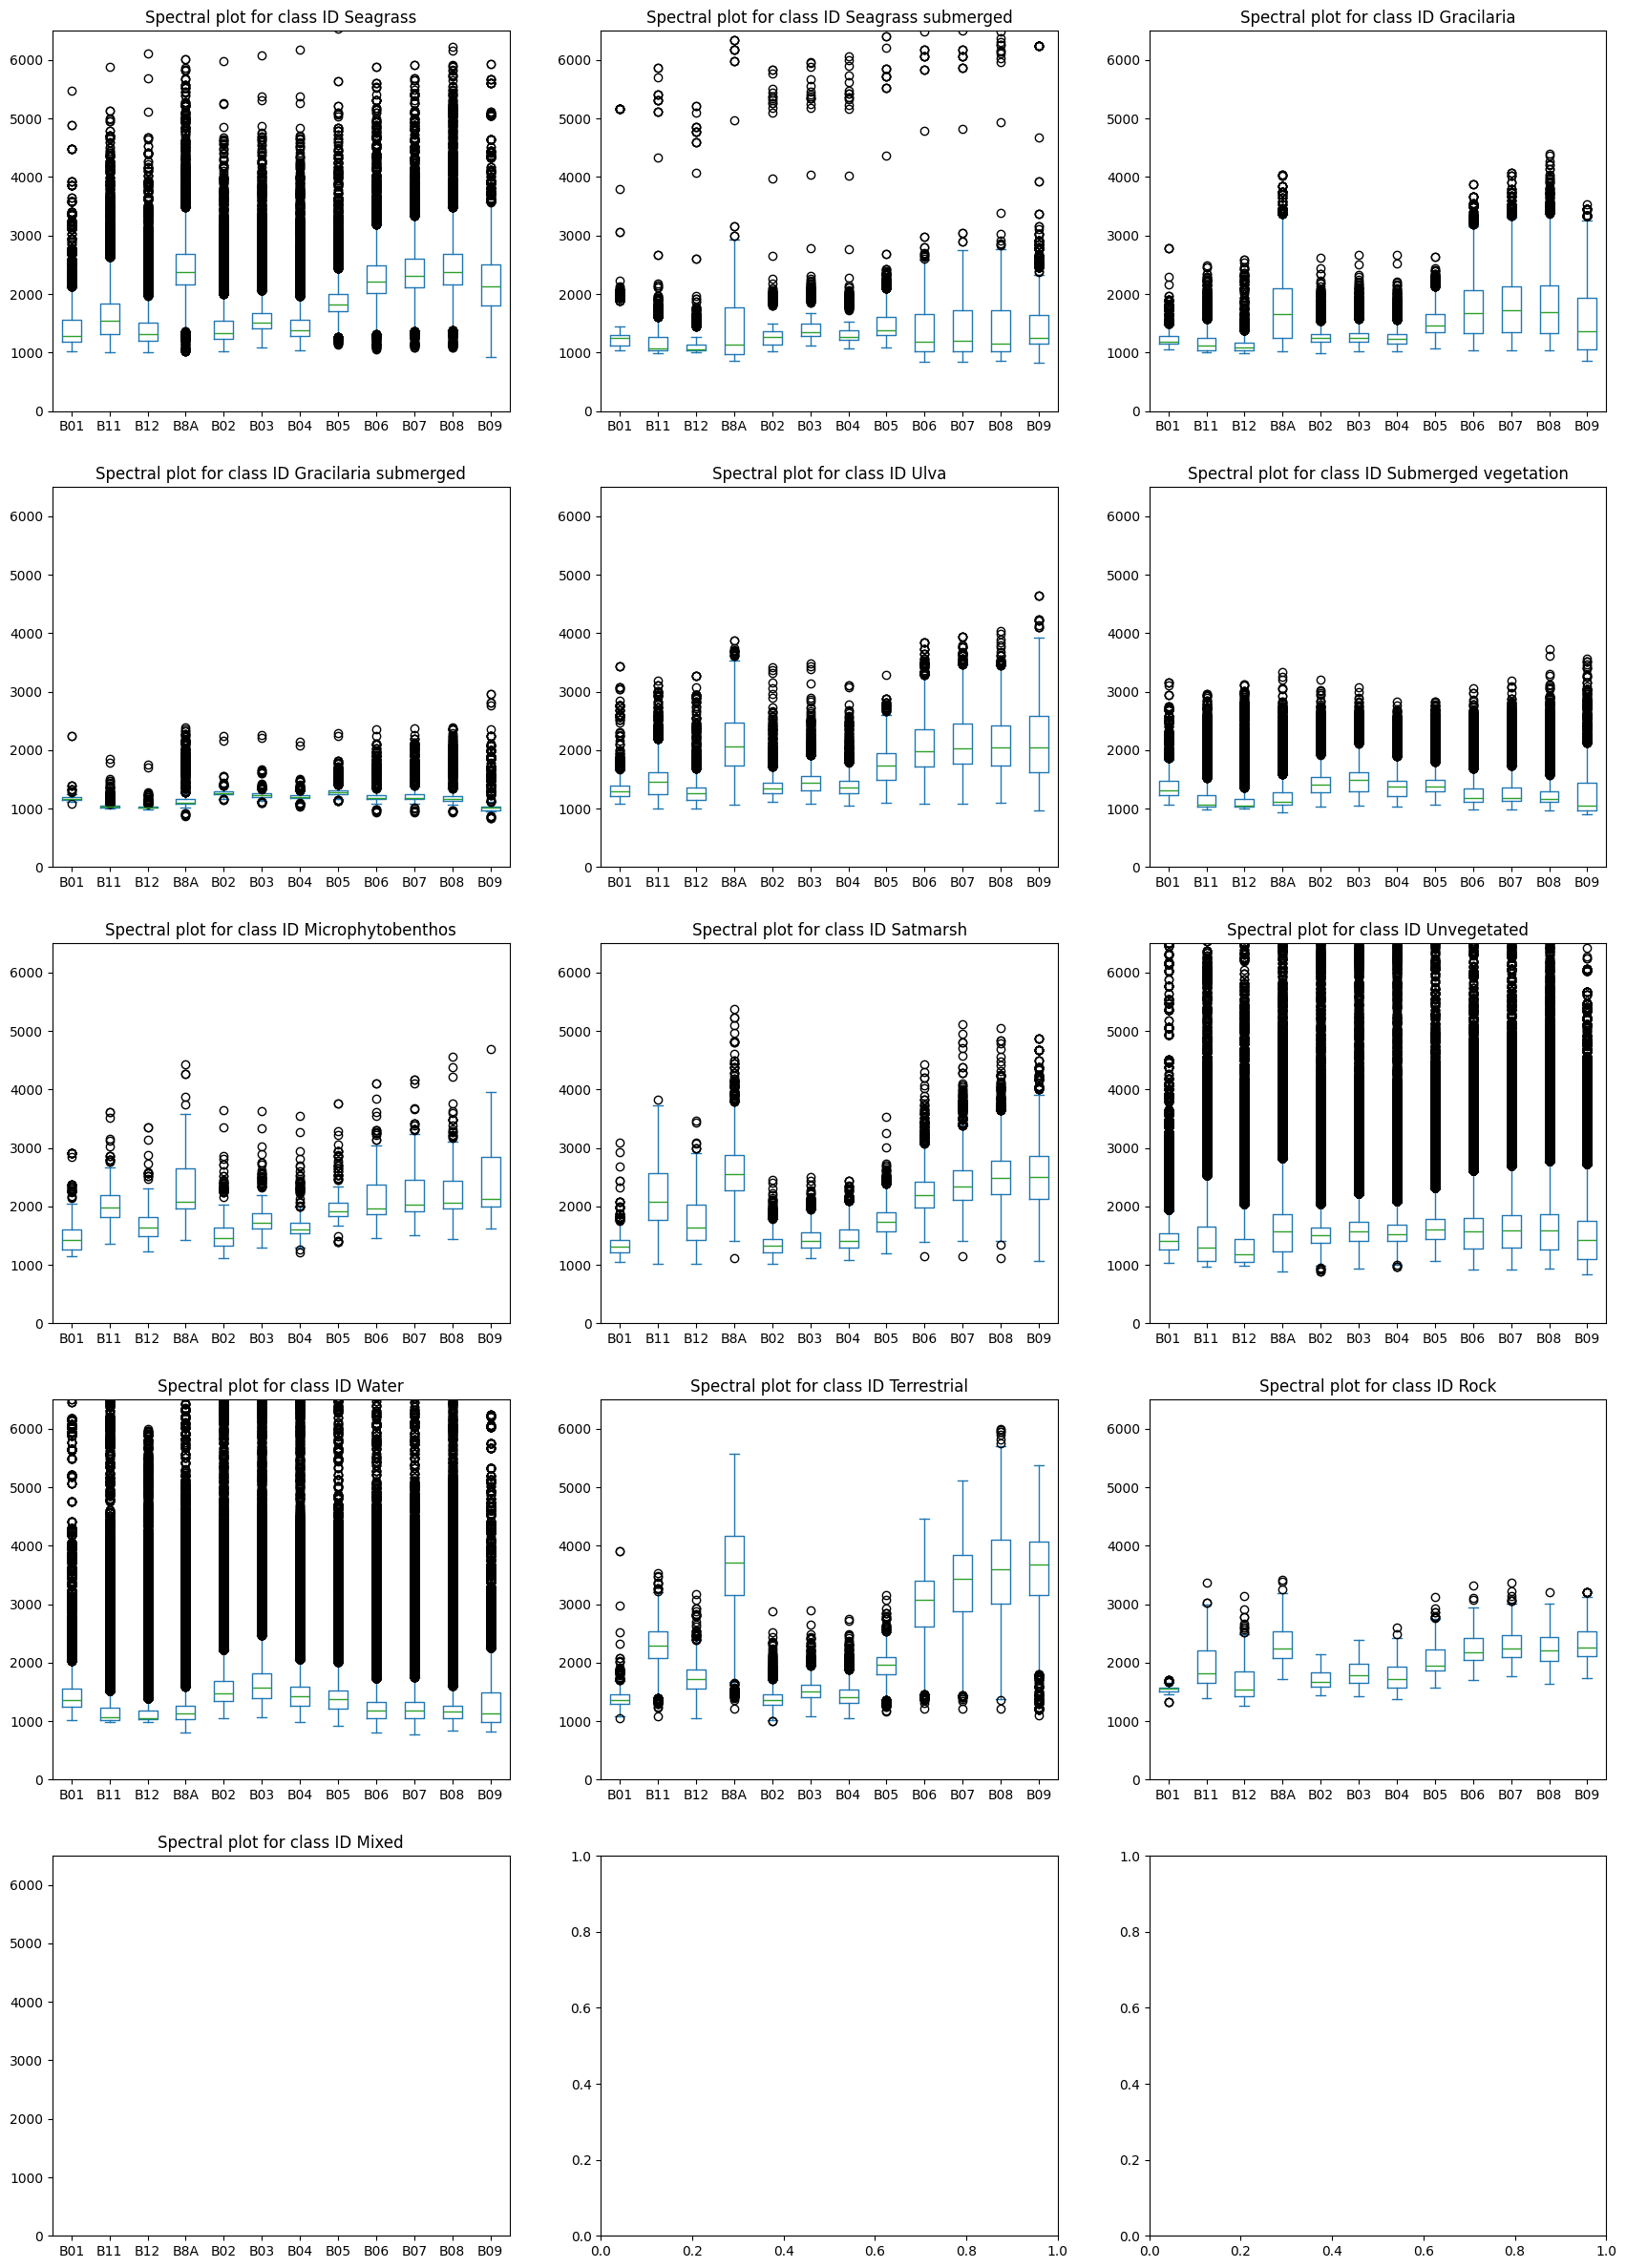

In [18]:
plotting.plot_training_data_class_distribution(training_dataframe=training_dataframe, model_file=model_file,
                                               uav_labels_file=uav_labels_file, satellite_labels=satellite_classes)

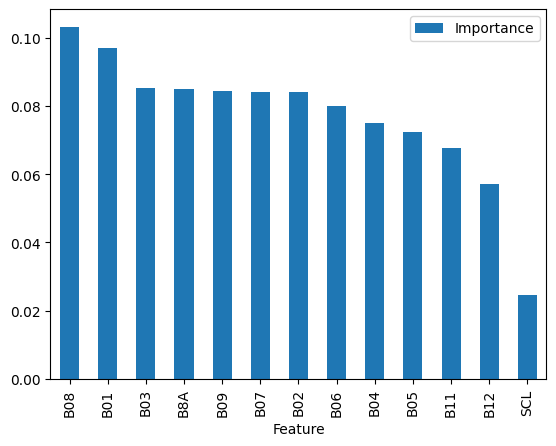

In [19]:
plotting.plot_model_feature_importance(training_dataframe=training_dataframe, model_file=model_file)

# Validate
* Predict
* Confusion matrix at UAV resolution
* Confusion matrix at Satellite resolution - take mode of UAV data

	Predict 25136 samples
Satellite training classes present: ['Seagrass', 'Seagrass submerged', 'Gracilaria', 'Gracilaria submerged', 'Ulva', 'Submerged vegetation', 'Microphytobenthos', 'Satmarsh', 'Unvegetated', 'Water', 'Terrestrial', 'Rock']. Predicted classes present: ['Seagrass', 'Seagrass submerged', 'Gracilaria', 'Gracilaria submerged', 'Ulva', 'Submerged vegetation', 'Microphytobenthos', 'Satmarsh', 'Unvegetated', 'Water', 'Terrestrial', 'Rock']. 


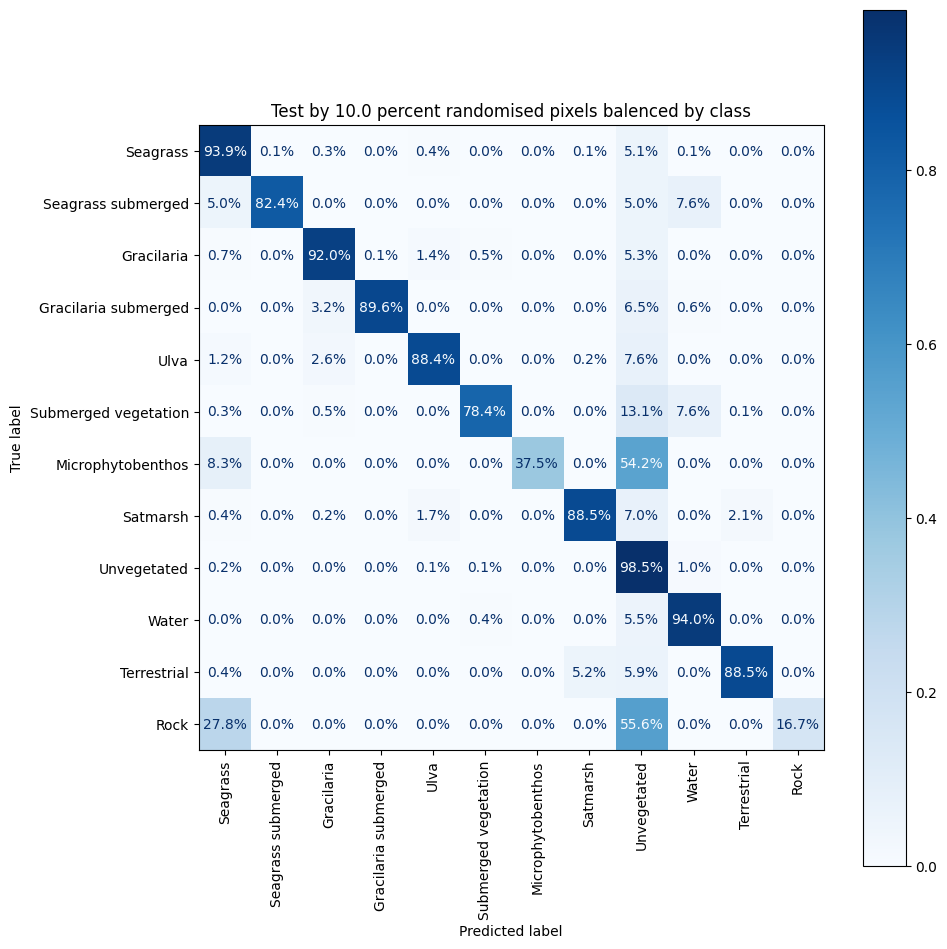

In [20]:
if not test_prediction_file.exists():
    model_feature_names_file = model_file.with_name(f"{model_file.stem}_feature_names.csv")
    predictions = training.predict_samples(test_dataframe=test_dataframe, model_file=model_file, model_feature_names_file=model_feature_names_file)
    # save predictions with actual to csv
    predictions.to_csv(test_prediction_file, index=False)
else:
    print(f"Prediction file '{test_prediction_file.name}' already eixsts. Delete if you want to repredict.")
    predictions = pandas.read_csv(test_prediction_file)
    
print(
    f"Satellite training classes present: {[key for key, value in satellite_classes.items() if value in predictions['satellite_class_id'].unique()]}. "
    f"Predicted classes present: {[key for key, value in satellite_classes.items() if value in predictions['predicted_class_id'].unique()]}. "
     )

plot_filename = test_prediction_file.with_name( f"{test_prediction_file.stem}_confusion_matrix.png")
plot_title = f"Test by {test_threshold*100} percent randomised pixels balenced by class"

training.confusion_matrix_of_pixels(
    predictions=predictions,
    satellite_classes=satellite_classes,
    plot_filename=plot_filename,
    plot_title=plot_title
);
